In [ ]:
# Hyperparameter Optimization using Genetic Algorithms (GA)

# Phase 1: Data Loading & Exploratory Data Analysis
# In this section, we load the Diabetes progression dataset, visualize the distribution of features and the target variable, and 
# normalize the data for neural network training.

In [1]:
# --- Core Libraries ---
import random
import numpy as np
import matplotlib.pyplot as plt
# --- Machine Learning & Deep Learning ---
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

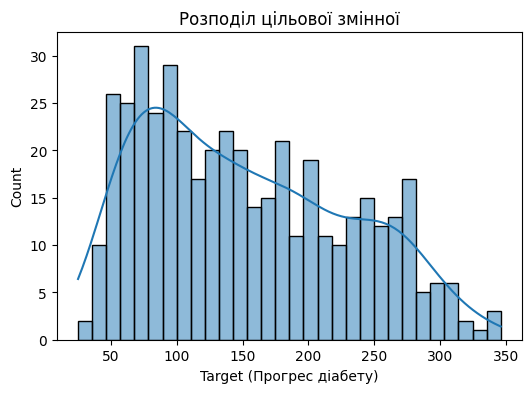

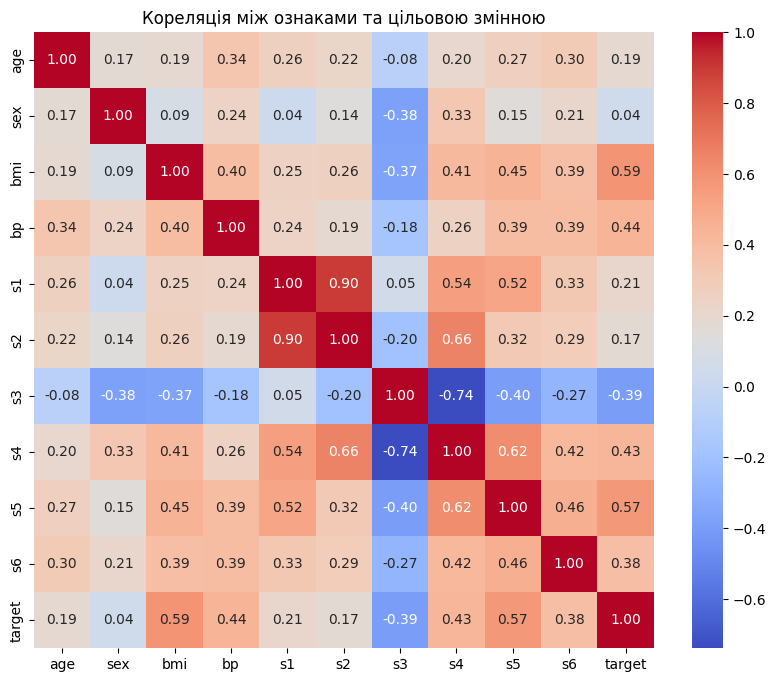

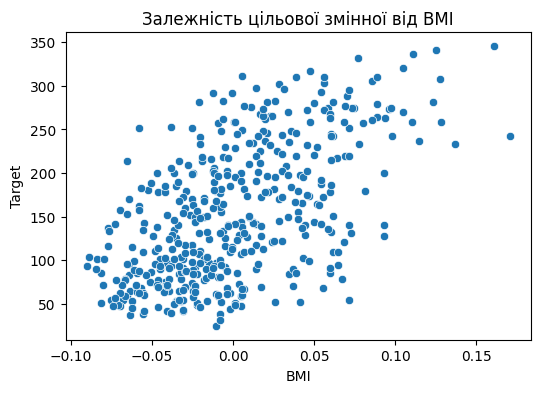

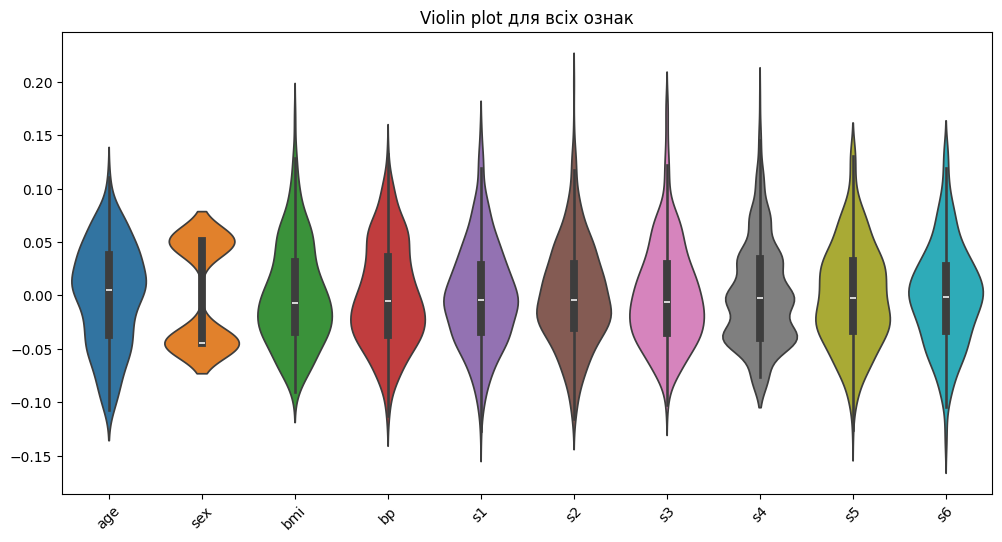

In [31]:
# --- 1. Load Dataset ---
data = load_diabetes()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# --- 2. Exploratory Data Analysis (EDA) ---

# Target Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['target'], bins=30, kde=True)
plt.xlabel("Target (Прогрес діабету)")
plt.title("Розподіл цільової змінної")
plt.show()

# Feature Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Кореляція між ознаками та цільовою змінною")
plt.show()

# BMI vs Target Scatter
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='target', data=df)
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Залежність цільової змінної від BMI")
plt.show()

# Feature Distributions (Violin Plot)
plt.figure(figsize=(12,6))
sns.violinplot(data=df[feature_names])
plt.xticks(rotation=45)
plt.title("Violin plot для всіх ознак")
plt.show()

In [33]:
# --- 3. Data Splitting & Scaling ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Phase 2: Genetic Algorithm Definition
# We define the components of the Genetic Algorithm to search for optimal MLP hyperparameters 
# (neurons per layer, activation functions, batch size, learning rate). 
# The fitness function evaluates the Mean Squared Error (MSE) on the validation set.

Покоління 1, кращий MSE: 2899.04
Покоління 2, кращий MSE: 2850.39
Покоління 3, кращий MSE: 2805.21
Покоління 4, кращий MSE: 2802.43
Покоління 5, кращий MSE: 2885.31

Найкращі параметри MLP:
Neurons layer1: 64, Neurons layer2: 64
Activation: relu, Batch size: 32, Learning rate: 0.005


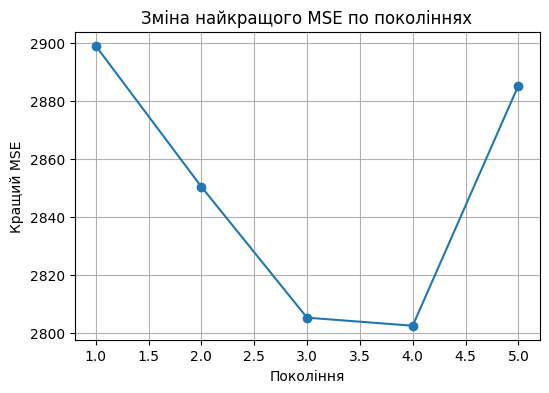

In [36]:
# --- 1. Genetic Algorithm Parameters ---

# --- Параметри GA ---
population_size = 6
generations = 5
mutation_rate = 0.3

# Search Space (Genes)
neurons_options = [32, 64, 128]
activations = ['relu', 'tanh']
batch_sizes = [16, 32, 64]
learning_rates = [0.001, 0.005, 0.01]

# --- 2. Initialization ---
def generate_population():
    pop = []
    for _ in range(population_size):
        chromosome = [
            np.random.choice(neurons_options),
            np.random.choice(neurons_options),
            np.random.choice(len(activations)),
            np.random.choice(batch_sizes),
            np.random.choice(learning_rates)
        ]
        pop.append(chromosome)
    return pop

# --- 3. Fitness Function ---
def fitness(chromosome):
    neurons1, neurons2, act_idx, batch_size, lr = chromosome
    activation = activations[act_idx]
    
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(neurons1, activation=activation),
        Dense(neurons2, activation=activation),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )
    # The fitness score is the final validation loss (lower is better)
    return history.history['val_loss'][-1]

# --- 4. Selection, Crossover & Mutation ---
def selection(pop, fits):
    # Select the top 50% of the population based on fitness
    idx = np.argsort(fits)
    return [pop[i] for i in idx[:len(pop)//2]]

def crossover(p1, p2):
    # Single-point crossover
    point = np.random.randint(1, len(p1)-1)
    return p1[:point]+p2[point:], p2[:point]+p1[point:]

def mutate(chrom):
    # Randomly mutate a single gene based on the mutation rate
    if np.random.rand() < mutation_rate:
        gene_idx = np.random.randint(len(chrom))
        if gene_idx in [0,1]:
            chrom[gene_idx] = np.random.choice(neurons_options)
        elif gene_idx == 2:
            chrom[gene_idx] = np.random.choice(len(activations))
        elif gene_idx == 3:
            chrom[gene_idx] = np.random.choice(batch_sizes)
        elif gene_idx == 4:
            chrom[gene_idx] = np.random.choice(learning_rates)
    return chrom

In [ ]:
# Phase 3: Executing the Evolutionary Process
# We run the Genetic Algorithm over a defined number of generations. In each iteration, chromosomes are evaluated, selected, crossed over, and 
# mutated to evolve better network configurations.

In [ ]:
# --- GA Loop ---
population = generate_population()
best_fits_per_gen = []

for gen in range(generations):
    fits = [fitness(ch) for ch in population]
    best_fits_per_gen.append(min(fits))
    print(f"Покоління {gen+1}, кращий MSE: {min(fits):.2f}")
    
    selected = selection(population, fits)
    # Generate new population
    children = []
    while len(children)+len(selected) < population_size:
        p1, p2 = random.sample(selected, 2)
        c1, c2 = crossover(p1, p2)
        children.append(mutate(c1))
        if len(children)+len(selected) < population_size:
            children.append(mutate(c2))
    population = selected + children

# --- Extract the Optimal Chromosome ---
fits = [fitness(ch) for ch in population]
best_idx = np.argmin(fits)
best_chrom = population[best_idx]
best_neurons1, best_neurons2, best_act_idx, best_batch_size, best_lr = best_chrom
best_activation = activations[best_act_idx]

print("\nНайкращі параметри MLP:")
print(f"Neurons layer1: {best_neurons1}, Neurons layer2: {best_neurons2}")
print(f"Activation: {best_activation}, Batch size: {best_batch_size}, Learning rate: {best_lr}")

# --- Plot Convergence ---
plt.figure(figsize=(6,4))
plt.plot(range(1, generations+1), best_fits_per_gen, marker='o')
plt.xlabel("Покоління")
plt.ylabel("Кращий MSE")
plt.title("Зміна найкращого MSE по поколіннях")
plt.grid(True)
plt.show()

In [ ]:
# Phase 4: Comparative Analysis (Optimized vs Baseline)
# We train the final model using the parameters discovered by the Genetic Algorithm and compare its performance against a standard baseline MLP.

In [37]:
# --- 1. Train GA-Optimized Model ---
best_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(best_neurons1, activation=best_activation),
    Dense(best_neurons2, activation=best_activation),
    Dense(1)
])
best_model.compile(optimizer=Adam(learning_rate=best_lr), loss='mse', metrics=['mae'])
best_model.summary()

Model: "sequential_85"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_255 (Dense)                    │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_256 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_257 (Dense)                    │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=best_batch_size,
    verbose=0
)

In [39]:
# --- 2. Evaluate best model ---
mse, mae = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")

Test MSE: 2756.89
Test MAE: 40.89


In [41]:
# --- 3. Prediction on the test sample ---
y_pred = best_model.predict(X_test).flatten()
print("\nПорівняння реальних і прогнозованих значень (перші 5):")
for i in range(5):
    print(f"Real: {y_test[i]:.1f}, Pred: {y_pred[i]:.1f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Порівняння реальних і прогнозованих значень (перші 5):
Real: 219.0, Pred: 168.5
Real: 70.0, Pred: 180.1
Real: 202.0, Pred: 159.7
Real: 230.0, Pred: 302.2
Real: 111.0, Pred: 99.2


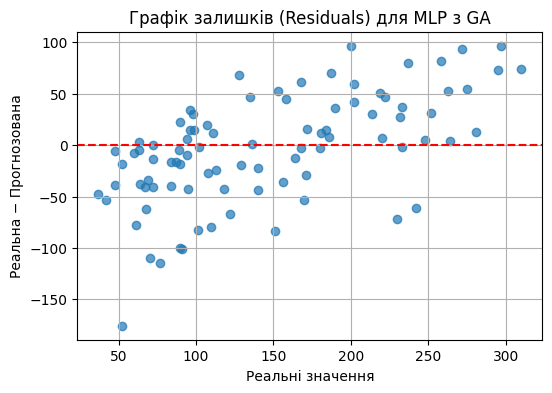

         Residual
count   89.000000
mean    -4.006419
std     52.649619
min   -175.641983
25%    -39.209145
50%     -2.117676
75%     31.520630
max     96.656685


In [46]:
# --- 4. Residuals analysis  ---
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_test, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')  # лінія нульової помилки
plt.xlabel("Реальні значення")
plt.ylabel("Реальна − Прогнозована")
plt.title("Графік залишків (Residuals) для MLP з GA")
plt.grid(True)
plt.show()


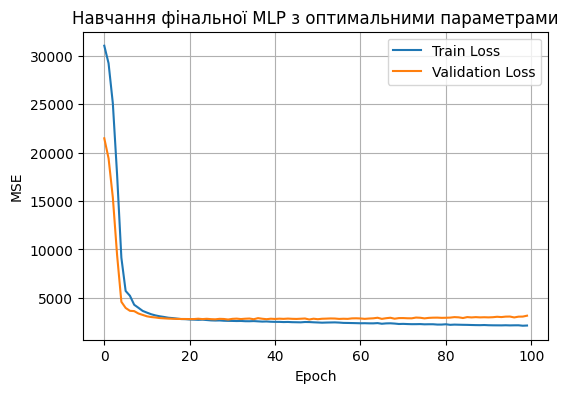

In [42]:
# --- 5. Training loss graph ---
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Навчання фінальної MLP з оптимальними параметрами")
plt.legend()
plt.grid(True)
plt.show()

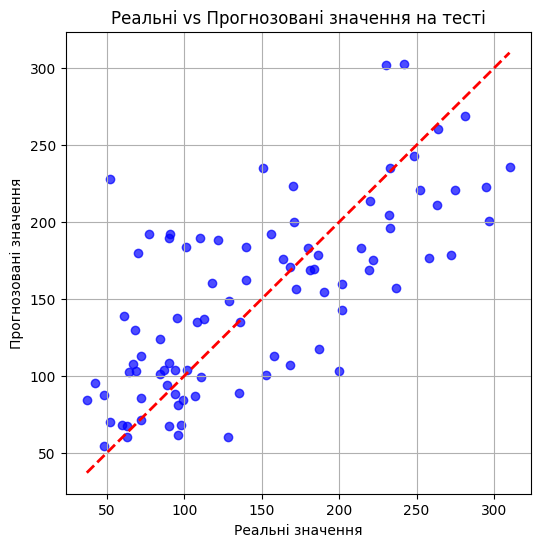

In [45]:
# --- 6. Graph of actual vs. predicted values ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Реальні значення")
plt.ylabel("Прогнозовані значення")
plt.title("Реальні vs Прогнозовані значення на тесті")
plt.grid(True)
plt.show()


In [47]:
# --- 7. Test MLP without GA (typical parameters) ---
base_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

base_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Learning
history_base = base_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# Evaluation on test sample
mse_base, mae_base = base_model.evaluate(X_test, y_test, verbose=0)
print(f"Base MLP Test MSE: {mse_base:.2f}")
print(f"Base MLP Test MAE: {mae_base:.2f}")


Base MLP Test MSE: 2905.91
Base MLP Test MAE: 43.13


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000182D32C96C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


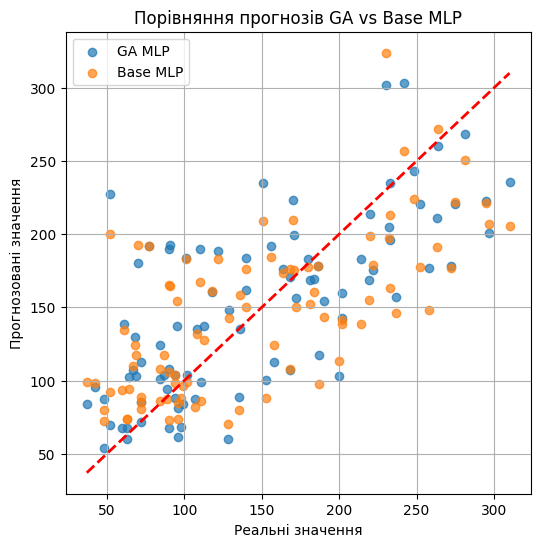

In [48]:
# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, label='GA MLP')
plt.scatter(y_test, base_model.predict(X_test).flatten(), alpha=0.7, label='Base MLP')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Реальні значення")
plt.ylabel("Прогнозовані значення")
plt.title("Порівняння прогнозів GA vs Base MLP")
plt.legend()
plt.grid(True)
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


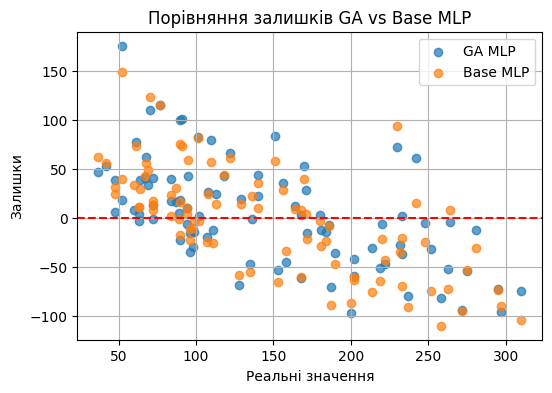

In [49]:
# Residuals Comparison
residuals_ga = y_pred - y_test
residuals_base = base_model.predict(X_test).flatten() - y_test

plt.figure(figsize=(6,4))
plt.scatter(y_test, residuals_ga, alpha=0.7, label='GA MLP')
plt.scatter(y_test, residuals_base, alpha=0.7, label='Base MLP')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Реальні значення")
plt.ylabel("Залишки")
plt.title("Порівняння залишків GA vs Base MLP")
plt.legend()
plt.grid(True)
plt.show()

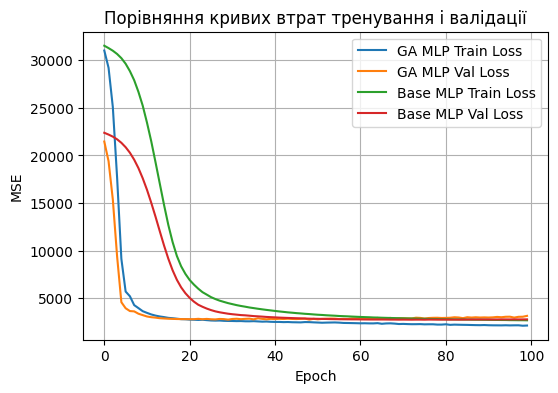

In [51]:
# Learning Curves Comparison
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='GA MLP Train Loss')
plt.plot(history.history['val_loss'], label='GA MLP Val Loss')
plt.plot(history_base.history['loss'], label='Base MLP Train Loss')
plt.plot(history_base.history['val_loss'], label='Base MLP Val Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Порівняння кривих втрат тренування і валідації")
plt.legend()
plt.grid(True)
plt.show()